In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from pathlib import Path
import sys


# Path to UVEX calibration code
code_dir = Path(
    "/Users/hannahgulick/Documents/Research/UVEX/uvex_insim/"
    "irdb/UVEX/code"
)

sys.path.insert(0, str(code_dir))


from detector_calibration import (
    generate_synthetic_read_noise,
    use_read_noise_array,write_read_noise_calibration)

============================================================
 
 Provisional UVEX read-noise RMS calibration map

 This creates and visualizes a synthetic per-pixel read-noise RMS map for
 simulations until measured detector calibration maps exist.

 FITS values represent sigma_RN in e-/pixel/read.
 They are NOT a realization of read noise.
 
 ============================================================


### Setup read noise map

In [2]:
read_noise_map = generate_synthetic_read_noise(
    mean_read_noise=5.0,
    pixel_variation=0.2,
)


#to change to array instead of synthetic:
'''measured_read_noise = np.load("test_read_noise_array.npy")

read_noise_map = use_read_noise_array(
    measured_read_noise
)'''

'measured_read_noise = np.load("test_read_noise_array.npy")\n\nread_noise_map = use_read_noise_array(\n    measured_read_noise\n)'

### Save read noise map as FITS

In [5]:
#############################################

# Output filename
save_filename = "UVIM_DET_read_noise_RN5p0_var0p2.fits"

output_dir = Path(
    "/Users/hannahgulick/Documents/Research/UVEX/uvex_insim/"
    "irdb/UVEX/data_files"
)

DET_ID = 'A1'

#############################################


In [6]:
write_read_noise_calibration(
    read_noise_map,
    save_filename,
    detector_id=DET_ID,
    output_dir=output_dir,
)

Saved:     /Users/hannahgulick/Documents/Research/UVEX/uvex_insim/irdb/UVEX/data_files/UVIM_DET_read_noise_RN5p0_var0p2.fits
Median RN: 5.000 e-
Mean RN:   5.000 e-
Min RN:    3.956 e-
Max RN:    6.062 e-


#### Plot FITS and Read Noise Values

In [7]:
def plot_read_noise_map(read_noise_map, detector_id=None):

    median_rn = np.nanmedian(read_noise_map)
    mean_rn = np.nanmean(read_noise_map)
    std_rn = np.nanstd(read_noise_map)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 6)
    )

    # -------------------------
    # Spatial map
    # -------------------------

    # Tight display range around the main detector population
    vmin = median_rn - 3 * std_rn
    vmax = median_rn + 3 * std_rn

    im = axes[0].imshow(
        read_noise_map,
        origin="lower",
        vmin=vmin,
        vmax=vmax,
    )

    cbar = plt.colorbar(im, ax=axes[0])
    cbar.set_label("Read noise RMS [e-/pixel/read]")

    axes[0].set_xlabel("X pixel")
    axes[0].set_ylabel("Y pixel")
    axes[0].set_title("Read-noise map")


    # -------------------------
    # Distribution
    # -------------------------

    # Focus histogram on the main read-noise population
    hist_min = median_rn - 5 * std_rn
    hist_max = median_rn + 5 * std_rn

    main_population = read_noise_map[
        (read_noise_map >= hist_min) &
        (read_noise_map <= hist_max)
    ]

    axes[1].hist(
        main_population.ravel(),
        bins=150,
        histtype="step"
    )

    axes[1].axvline(
        median_rn,
        linestyle="--",
        label=f"Median = {median_rn:.3f} e-"
    )

    axes[1].set_xlim(hist_min, hist_max)

    axes[1].set_xlabel("Read noise RMS [e-/pixel/read]")
    axes[1].set_ylabel("Number of pixels")
    axes[1].set_title("Read-noise distribution")
    axes[1].legend()


    # -------------------------
    # Overall title
    # -------------------------

    if detector_id is not None:
        fig.suptitle(
            f"UVEX Detector {detector_id} Read Noise",
            fontsize=14
        )

    plt.tight_layout()
    plt.show()

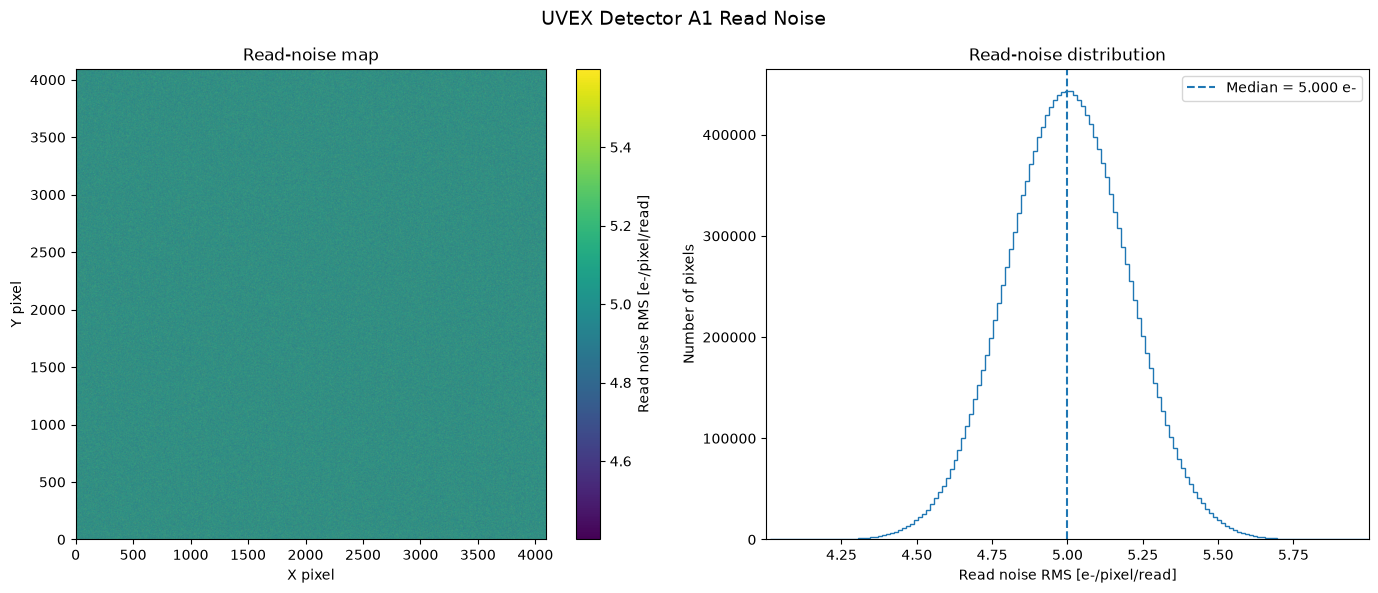

In [8]:
# Inspect it
plot_read_noise_map(
    read_noise_map,
    detector_id=DET_ID
)


In [9]:
print("Min:        ", np.min(read_noise_map))
print("Max:        ", np.max(read_noise_map))
print("Mean:       ", np.mean(read_noise_map))
print("Median:     ", np.median(read_noise_map))
print("Std:        ", np.std(read_noise_map))
print("Unique vals:", len(np.unique(read_noise_map)))

Min:         3.9557667
Max:         6.0623684
Mean:        4.9999704
Median:      4.9999456
Std:         0.19995695
Unique vals: 2132560
